<a href="https://colab.research.google.com/github/sebastianvettel1212/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 3 — Statistical Experiments and Significance Testing (Eksperimen Statistik dan Uji Signifikansi)

**Buku:** *Practical Statistics for Data Scientists* — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly)

Notebook ini berisi:
1. **Reproduksi kode** seluruh contoh pada Bab 3 (Python: `pandas`, `NumPy`, `SciPy`, `statsmodels`, `Matplotlib`),
2. **Ringkasan** tiap subbab (*Key Ideas*), dan
3. **Penjelasan teori** dalam Bahasa Indonesia.

---

## Daftar Isi
0. Persiapan: Library & Dataset
1. A/B Testing
2. Hypothesis Tests (Uji Hipotesis)
3. Resampling (Permutation Test)
4. Statistical Significance dan P-Value
5. t-Tests
6. Multiple Testing
7. Degrees of Freedom
8. ANOVA
9. Chi-Square Test
10. Multi-Arm Bandit Algorithm
11. Power dan Sample Size
12. Ringkasan Bab

## 0. Persiapan: Library & Dataset

Dataset Bab 3 (dari repositori resmi buku): `web_page_data.csv`, `four_sessions.csv`, `click_rates.csv`, dan `imanishi_data.csv`. Fungsi `path_data()` memakai file lokal di `data/` bila ada, atau mengunduh dari GitHub secara otomatis.

In [1]:
# Jalankan sel ini (hapus tanda #) bila library belum terpasang
!pip install pandas numpy scipy statsmodels matplotlib

In [2]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [3]:
# Lokasi dataset: folder lokal 'data/' atau, bila tidak ada, langsung dari GitHub
DATA_DIR = Path('data')
RAW_URL = ('https://raw.githubusercontent.com/gedeck/'
           'practical-statistics-for-data-scientists/master/data/')

def path_data(nama_file):
    lokal = DATA_DIR / nama_file
    return lokal if lokal.exists() else RAW_URL + nama_file

WEB_PAGE_DATA_CSV = path_data('web_page_data.csv')
FOUR_SESSIONS_CSV = path_data('four_sessions.csv')
CLICK_RATE_CSV    = path_data('click_rates.csv')
IMANISHI_CSV      = path_data('imanishi_data.csv')

---
## 1. A/B Testing

**A/B test** adalah eksperimen dengan **dua kelompok** untuk menguji mana dari dua perlakuan (produk, prosedur, dll.) yang lebih baik. Idealnya subjek **ditugaskan secara acak** ke tiap kelompok, sehingga perbedaan hasil dapat dikaitkan dengan perlakuan, bukan faktor lain.

**Istilah kunci**

| Istilah | Penjelasan |
|---|---|
| **Treatment** | Sesuatu (obat, harga, judul web) yang diberikan pada subjek |
| **Treatment group** | Kelompok yang menerima perlakuan tertentu |
| **Control group** | Kelompok yang tidak menerima perlakuan (atau perlakuan standar) |
| **Randomization** | Proses menetapkan subjek ke kelompok secara acak |
| **Subjects** | Unit (pengunjung web, pasien, dll.) yang diberi perlakuan |
| **Test statistic** | Metrik untuk mengukur efek perlakuan |

**Mengapa perlu kelompok kontrol?** Tanpa kontrol, kita tidak tahu apakah perubahan hasil berasal dari perlakuan atau dari faktor lain (musim, tren, dll.). Membandingkan dengan data historis juga rawan bias. **Mata buta (*blinding*)** (subjek atau pengamat tidak tahu kelompoknya) mengurangi bias.

**Mengapa hanya A vs B?** Satu perubahan pada satu waktu membuat efeknya dapat diisolasi. Hasil harus diukur dengan **satu metrik** yang ditentukan di awal agar tidak terjadi *cherry-picking*.

**Data yang dikumpulkan** untuk A/B test web biasanya: tayangan, klik, waktu sesi, konversi. Hasil dianalisis memakai uji hipotesis.

### Key Ideas
- Subjek ditugaskan ke dua kelompok, tiap kelompok mendapat perlakuan berbeda.
- Penugasan acak mencegah bias dan memastikan perbedaan kelompok kebetulan.
- Tentukan **hipotesis dan metrik** *sebelum* eksperimen berjalan.

---
## 2. Hypothesis Tests (Uji Hipotesis)

Uji hipotesis (*significance test*) menilai apakah efek yang tampak pada A/B test **nyata** atau hanya hasil **kebetulan acak**. Pikiran manusia cenderung meremehkan keacakan, sehingga kita perlu alat formal.

**Istilah kunci**
- **Null hypothesis ($H_0$)**: tidak ada perbedaan; efek hanya akibat kebetulan.
- **Alternative hypothesis ($H_A$)**: kebalikan dari $H_0$, yaitu ada efek nyata.
- **One-way test**: hanya menghitung peluang kesalahan pada satu arah (mis. B lebih baik dari A).
- **Two-way test**: menghitung peluang kesalahan di kedua arah.

**Logika uji:** kita **berasumsi** $H_0$ benar (semua perlakuan sama, perbedaan hanya kebetulan), lalu menanyakan *seberapa mungkin* hasil seekstrem yang diamati muncul. Bila sangat jarang, kita menolak $H_0$.

**Kenapa $H_0$?** Kita ingin membuktikan bahwa perbedaan *tidak* bisa dijelaskan kebetulan, sehingga harus dibandingkan dengan model yang hanya memuat kebetulan. **One-way vs two-way**: tes satu arah dipakai bila kita hanya peduli satu arah (B lebih baik); tes dua arah lebih konservatif dan lebih umum karena melindungi dari kesimpulan salah di kedua arah.

### Key Ideas
- Hipotesis nol: efek hanya kebetulan. Hipotesis alternatif: efek nyata.
- Uji hipotesis dirancang agar kita **tidak tertipu keacakan**.
- Pilih uji satu atau dua arah **sebelum** melihat data.

---
## 3. Resampling

**Resampling** berarti mengambil sampel berulang dari data yang diamati untuk menaksir variabilitas statistik atau menilai model. Ada dua jenis utama: **bootstrap** (Bab 2) dan **permutation test** (uji permutasi).

**Istilah kunci**
- **Permutation test**: prosedur menggabungkan dua atau lebih sampel, lalu menarik ulang secara acak (tanpa pengembalian) untuk membentuk kelompok baru.
- **Resampling**: mengambil sampel berulang dari data yang diamati.
- **With/without replacement**: dengan/tanpa pengembalian.

### 3.1 Permutation Test
Langkah-langkah:
1. **Gabungkan** hasil dari kelompok A dan B menjadi satu set data.
2. **Acak** gabungan itu, lalu **tarik** secara acak (tanpa pengembalian) sampel sebesar kelompok A (sebut $n_A$), sisanya kelompok B.
3. Hitung statistik (mis. selisih rata-rata A dan B) pada pembagian acak ini.
4. **Ulangi** $R$ kali sehingga diperoleh **distribusi permutasi** statistik.
5. Bandingkan selisih **teramati** dengan distribusi permutasi. Bila selisih teramati berada di dalam kisaran normal distribusi permutasi, perbedaan itu bisa jadi kebetulan; bila di luar (ekstrem), itu **signifikan secara statistik**.

### 3.2 Contoh: Web Stickiness
Sebuah perusahaan menguji dua versi halaman web (Page A dan Page B) berdasarkan **lama sesi** pengunjung (lebih lama = lebih "lengket"). Data berisi 36 sesi (21 untuk A, 15 untuk B). Selisih rata-rata B dan A diamati, lalu diuji dengan permutasi.

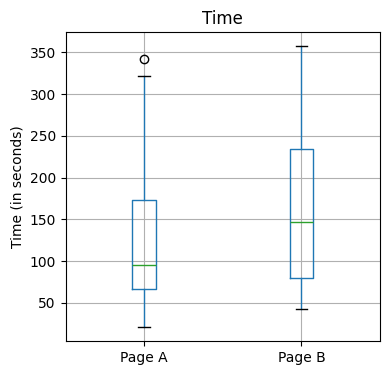

In [4]:
# Data web stickiness: waktu sesi (dalam detik)
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
session_times.Time = 100 * session_times.Time

ax = session_times.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [5]:
# Selisih rata-rata teramati (B - A)
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(mean_b - mean_a)

35.66666666666667


In [6]:
# Fungsi permutation test: acak indeks, hitung selisih rata-rata B - A
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print(perm_fun(session_times.Time, nA, nB))

-27.87619047619046


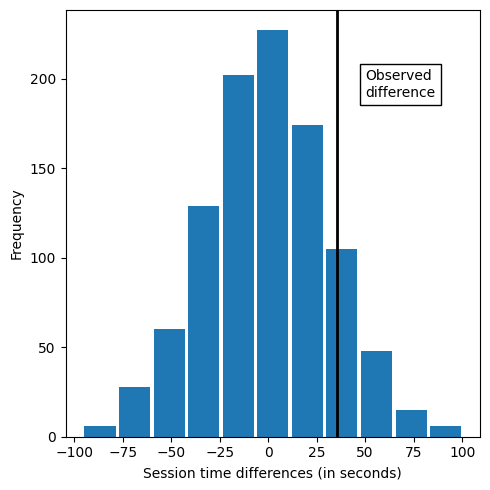

In [7]:
# 1000 permutasi, lalu histogram distribusi permutasi
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor': 'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [8]:
# Proporsi permutasi yang selisihnya >= selisih teramati = p-value (satu arah)
perm_diffs = np.array(perm_diffs)
print(np.mean(perm_diffs > mean_b - mean_a))

0.121


**Interpretasi:** garis hitam (selisih teramati) berada di dalam sebaran selisih hasil permutasi, dan sekitar seperempat permutasi acak menghasilkan selisih sebesar atau lebih besar dari yang teramati. Artinya, perbedaan antara Page A dan Page B **bisa saja hanya kebetulan** (tidak signifikan secara statistik).

### 3.3 Exhaustive dan Bootstrap Permutation Test
- **Exhaustive (exact) permutation test**: mencoba **semua** pembagian yang mungkin, sehingga hasilnya eksak. Hanya praktis untuk sampel kecil, karena jumlah kombinasi meledak.
- **Bootstrap permutation test**: pengambilan sampel dilakukan **dengan pengembalian**, sehingga mensimulasikan juga variasi pengambilan sampel dari populasi, bukan hanya pengacakan penugasan.

Pada praktiknya, ketiga pendekatan (permutasi acak, eksak, dan bootstrap) biasanya memberi hasil yang **serupa** bila sampel cukup besar.

### 3.4 Permutation Tests: Intisari untuk Data Science
Uji permutasi berguna karena **tidak membutuhkan asumsi** bahwa data berdistribusi normal, tidak perlu rumus rumit, dan fleksibel untuk statistik apa pun. Ia mendukung **inferensi berbasis simulasi** yang intuitif dan menjadi alternatif bagi uji klasik berbasis rumus.

### Key Ideas
- Uji permutasi: gabungkan kelompok, acak ulang pembagiannya, hitung statistik berulang kali.
- Bandingkan nilai teramati dengan distribusi permutasi untuk menilai signifikansi.
- Tidak memerlukan asumsi distribusi; cocok untuk berbagai statistik.

---
## 4. Statistical Significance dan P-Value

**Statistical significance** menunjukkan apakah hasil eksperimen **lebih ekstrem** daripada yang biasa muncul akibat kebetulan.

**Istilah kunci**
- **P-value**: bila hipotesis nol benar, **peluang** memperoleh hasil seekstrem (atau lebih) dari yang teramati.
- **Alpha ($\alpha$)**: ambang peluang "tidak biasa" yang kita tetapkan di awal; hasil dengan p-value di bawah $\alpha$ dianggap signifikan.
- **Type 1 error**: menyimpulkan efek nyata padahal hanya kebetulan (*false positive*).
- **Type 2 error**: menyimpulkan efek hanya kebetulan padahal nyata (*false negative*).

**Contoh buku (konversi):** perbandingan dua harga produk. Harga A: 200 konversi dari 23.739 tayangan; harga B: 182 konversi dari 22.588 tayangan. Selisih konversi teramati lalu diuji dengan permutasi (kotak berisi 382 angka 1 dan 45.945 angka 0, diacak, dibagi menjadi dua kelompok).

Observed difference: 0.0368%


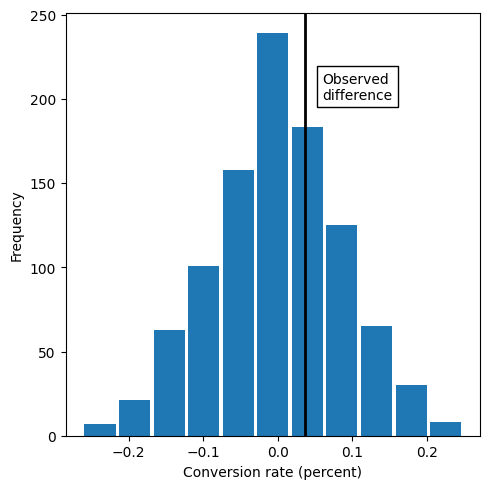

In [9]:
# Selisih konversi teramati (dalam persen)
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')

# Kotak berisi 382 "1" (konversi) dan 45.945 "0" (tidak konversi)
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor': 'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### P-Value
P-value dihitung sebagai proporsi hasil permutasi yang selisihnya **sama atau lebih ekstrem** daripada yang teramati.

In [10]:
# np.mean pada list boolean = proporsi True
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


In [11]:
# Pendekatan analitik dengan uji chi-square pada tabel kontingensi 2x2
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value for single sided test: {p_value / 2:.4f}')

p-value for single sided test: 0.3498


**Interpretasi:** p-value permutasi (sekitar 0,3) dan p-value analitik (sekitar 0,3) **sama-sama jauh di atas 0,05**. Perbedaan konversi antara harga A dan B tidak cukup kuat untuk disimpulkan sebagai efek nyata.

### Apa yang p-value *bukan*
P-value **tidak** menyatakan peluang hipotesis nol benar, dan **tidak** mengukur besar atau pentingnya efek. Pernyataan ASA (2016) mengingatkan: p-value tidak mengukur probabilitas bahwa hipotesis benar, kesimpulan tidak boleh hanya berdasarkan apakah p melewati ambang tertentu (mis. 0,05), dan signifikansi statistik bukan berarti signifikansi praktis.

### Type 1 dan Type 2 Error
- **Type 1 (false positive)**: menolak $H_0$ padahal benar. Peluangnya dikendalikan oleh $\alpha$.
- **Type 2 (false negative)**: gagal menolak $H_0$ padahal salah. Terkait **power** (lihat bagian 11).

### Key Ideas
- Signifikansi statistik = hasil melampaui yang wajar akibat kebetulan.
- P-value = peluang hasil seekstrem itu bila $H_0$ benar; **bukan** peluang $H_0$ benar.
- Ambang (mis. 0,05) bersifat konvensi, bukan batas ajaib.

---
## 5. t-Tests

**t-test** adalah uji klasik (berbasis rumus) untuk menguji perbedaan rata-rata dua kelompok. Statistik ujinya distandardisasi, dibandingkan dengan **distribusi t** (Bab 2). Versi *Welch* (`equal_var=False`) tidak mengasumsikan varians kedua kelompok sama.

Pada era komputasi, uji permutasi bisa memberi jawaban serupa tanpa asumsi, tetapi t-test tetap umum dipakai dan tersedia di semua perangkat lunak.

**Istilah kunci:** *test statistic* (metrik untuk perbedaan/efek), *t-statistic* (versi standar test statistic), *t-distribution* (distribusi referensi untuk membandingkan t-statistic).

Uji di bawah ini menguji apakah rata-rata waktu Page A **lebih kecil** daripada Page B.

In [12]:
# scipy: ttest_ind (dua sisi) => bagi dua untuk p-value satu sisi
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


In [13]:
# statsmodels: bisa langsung menentukan arah uji (alternative='smaller')
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time,
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


**Interpretasi:** p-value t-test (sekitar 0,14) lebih kecil dibandingkan hasil permutasi, tetapi tetap **di atas 0,05**; kesimpulan sama: perbedaan belum signifikan.

### Key Ideas
- t-test adalah uji standar untuk perbedaan rata-rata, berbasis distribusi t.
- Hasilnya biasanya mendekati hasil uji permutasi.
- Versi Welch tidak mengasumsikan varians sama.

---
## 6. Multiple Testing

Semakin banyak pengujian yang dilakukan pada data yang sama, semakin besar peluang menemukan hasil "signifikan" **secara kebetulan**. Ini masalah *multiple testing* (juga disebut *alpha inflation*).

**Istilah kunci**
- **Type 1 error**: menyimpulkan ada efek padahal tidak.
- **False discovery rate (FDR)**: proporsi "penemuan" yang sebenarnya salah.
- **Alpha inflation**: peluang false positive meningkat seiring jumlah uji.
- **Adjustment of p-values**: koreksi untuk banyak pengujian (mis. Bonferroni).
- **Overfitting**: pemodelan terhadap derau (*noise*).

**Contoh:** jika kita menguji 20 prediktor yang sebenarnya tak ada hubungannya dengan hasil, peluang paling tidak satu tampak signifikan di $\alpha = 0{,}05$ adalah $1-0{,}95^{20} \approx 64\%$. Dalam data science, ini berkaitan dengan *data mining*, *overfitting*, dan *vast search effect* (Bab 2).

**Solusi:** koreksi p-value (Bonferroni: bagi $\alpha$ dengan jumlah pengujian), kontrol FDR (Benjamini-Hochberg), dan terutama **validasi pada data holdout / eksperimen baru**.

### Key Ideas
- Banyak uji = banyak peluang hasil palsu yang "signifikan".
- Koreksi (Bonferroni, FDR) menurunkan risiko false positive.
- Dalam *machine learning*, gunakan data holdout / validasi silang.

In [14]:
# Tambahan: simulasi alpha inflation. 20 uji pada data murni derau, alpha = 0.05
rng = np.random.default_rng(0)
n_sim, n_uji, alpha = 2000, 20, 0.05
minimal_satu = 0
minimal_satu_bonf = 0
for _ in range(n_sim):
    p = np.array([stats.ttest_ind(rng.normal(size=30), rng.normal(size=30)).pvalue
                  for _ in range(n_uji)])
    minimal_satu += (p < alpha).any()
    minimal_satu_bonf += (p < alpha / n_uji).any()
print(f'Teori 1-(0.95)^20          : {1 - 0.95**20:.3f}')
print(f'Simulasi (tanpa koreksi)   : {minimal_satu / n_sim:.3f}')
print(f'Simulasi (koreksi Bonferroni): {minimal_satu_bonf / n_sim:.3f}')

Teori 1-(0.95)^20          : 0.642
Simulasi (tanpa koreksi)   : 0.644
Simulasi (koreksi Bonferroni): 0.048


---
## 7. Degrees of Freedom

**Degrees of freedom (derajat kebebasan, df)** adalah banyaknya nilai yang **bebas bervariasi** setelah ada batasan. Mis. bila rata-rata 5 angka dibuat tetap, hanya 4 angka yang bebas; angka kelima ditentukan. Karena itu simpangan baku sampel memakai pembagi $n-1$, bukan $n$ (agar estimasi varians tidak bias).

**Istilah kunci**
- **n atau sample size**: banyaknya observasi.
- **d.f.**: derajat kebebasan.

Konsep ini muncul pada distribusi t, chi-square, F (Bab 2) dan di regresi. Untuk data science, pemahaman mendalam df tidak terlalu penting karena jarang mempengaruhi keputusan secara langsung, kecuali untuk **faktor kategorikal pada regresi** (Bab 4): faktor dengan $P$ level menghasilkan $P-1$ kolom *dummy*, karena bila dimasukkan semua $P$ kolom akan terjadi **multikolinearitas sempurna**.

### Key Ideas
- df berasal dari penyesuaian estimasi pada sampel kecil.
- Perangkat lunak biasanya mengurus df secara otomatis.
- Penting pada regresi dengan variabel kategorikal (maksimum $P-1$ dummy).

In [15]:
# Tambahan: kenapa pembagi n-1? Bandingkan estimasi varians (populasi = 1) untuk n kecil
rng = np.random.default_rng(1)
data = rng.normal(0, 1, size=(100_000, 5))
print('Varians dibagi n   :', round(data.var(axis=1, ddof=0).mean(), 3), '(bias ke bawah)')
print('Varians dibagi n-1 :', round(data.var(axis=1, ddof=1).mean(), 3), '(tak bias, ~1)')

Varians dibagi n   : 0.798 (bias ke bawah)
Varians dibagi n-1 : 0.998 (tak bias, ~1)


---
## 8. ANOVA

**ANOVA (Analysis of Variance)** adalah uji statistik untuk **lebih dari dua kelompok**. Contoh: menguji 4 desain halaman web (Page 1 sampai Page 4) berdasarkan lama sesi. Melakukan banyak t-test berpasangan akan menaikkan risiko false positive (*multiple testing*), jadi digunakan satu uji **omnibus**.

**Istilah kunci**
- **Pairwise comparison**: pembandingan antara dua kelompok.
- **Omnibus test**: uji tunggal tentang apakah ada perbedaan di antara banyak kelompok.
- **Decomposition of variance**: pemisahan komponen variabilitas (keseluruhan, antar-kelompok, dalam-kelompok).
- **F-statistic**: rasio variabilitas antar-kelompok terhadap variabilitas dalam kelompok.
- **SS (sum of squares)**: jumlah kuadrat deviasi dari rata-rata.

**Pendekatan permutasi:** (1) gabungkan semua data, (2) acak dan bagi ke 4 kelompok sesuai ukuran asli, (3) hitung rata-rata tiap kelompok, (4) hitung **varians antar rata-rata kelompok**, (5) ulangi dan bandingkan dengan nilai teramati.

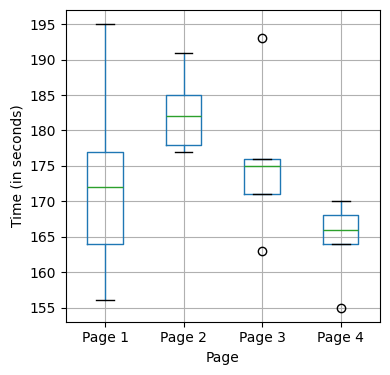

     Page  Time
0  Page 1   164
1  Page 2   178
2  Page 3   175
3  Page 4   155
4  Page 1   172


In [16]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

ax = four_sessions.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')
plt.tight_layout()
plt.show()
print(four_sessions.head())

In [17]:
# Varians rata-rata antar kelompok (teramati)
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655


In [18]:
# Satu kali permutasi: acak kolom Time, hitung varians rata-rata antar kelompok
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]

print(perm_test(four_sessions))

5.9866666666666895


Pr(Prob) 0.08433333333333333


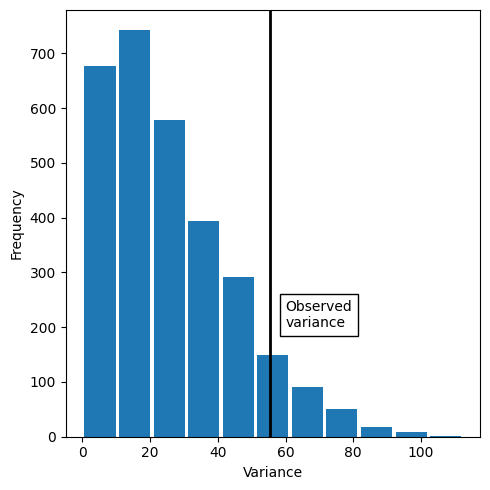

In [19]:
random.seed(1)
np.random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor': 'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretasi:** p-value permutasi sekitar 0,07 (di atas 0,05 tetapi relatif kecil), jadi perbedaan antar halaman **belum cukup meyakinkan** pada $\alpha=0{,}05$, namun tidak jauh dari batas.

### 8.1 F-Statistic
Seperti t-statistic untuk dua kelompok, **F-statistic** untuk ANOVA: rasio variabilitas **antar-kelompok** terhadap variabilitas **dalam kelompok**. Dibandingkan dengan distribusi F. Tabel ANOVA merangkum df, SS, rata-rata kuadrat (MS), F, dan p-value.

In [20]:
# Tabel ANOVA dengan statsmodels
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


In [21]:
# Alternatif: scipy f_oneway.
# Catatan: kode buku membagi dua statistik & p-value (res.statistic / 2, res.pvalue / 2)
# agar sama dengan versi R; di sini ditampilkan nilai asli dan nilai yang dibagi dua.
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time,
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic (asli) : {res.statistic:.4f}')
print(f'p-value (asli)     : {res.pvalue:.4f}')
print(f'F-Statistic (buku, /2): {res.statistic / 2:.4f}')
print(f'p-value (buku, /2)    : {res.pvalue / 2:.4f}')

F-Statistic (asli) : 2.7398
p-value (asli)     : 0.0776
F-Statistic (buku, /2): 1.3699
p-value (buku, /2)    : 0.0388


### 8.2 Two-Way ANOVA
**Two-way ANOVA** menguji efek **dua faktor** sekaligus (mis. jenis halaman dan jam akses), termasuk **interaksi** antar faktor. Prinsip dekomposisi variansnya sama, hanya ada lebih banyak sumber variabilitas. Di Python, ini hanya tersedia lewat `statsmodels`:

```python
formula = 'len ~ C(supp) + C(dose) + C(supp):C(dose)'
model = ols(formula, data).fit()
aov_table = anova_lm(model, typ=2)
```

### Key Ideas
- ANOVA = uji statistik untuk membandingkan **lebih dari dua** kelompok sekaligus.
- Statistik F: variabilitas antar-kelompok dibanding dalam kelompok.
- Two-way ANOVA menambahkan faktor kedua dan interaksi.

---
## 9. Chi-Square Test

Dipakai untuk **data hitungan (kategorikal)**, mis. klik pada tiga judul berita (A, B, C). Uji ini menilai apakah frekuensi pengamatan menyimpang dari yang diharapkan di bawah $H_0$ (tidak ada hubungan antar variabel).

**Istilah kunci**
- **Chi-square statistic**: ukuran seberapa jauh data teramati dari harapan.
- **Expected**: nilai yang diharapkan di bawah $H_0$.
- **Pearson residual**: $R = \dfrac{\text{Observed} - \text{Expected}}{\sqrt{\text{Expected}}}$
- Statistik chi-square = **jumlah kuadrat residual Pearson**.

### 9.1 Pendekatan Resampling
Data klik 3 judul (masing-masing 1000 tayangan): total klik 34, tidak ada klik 2966.

In [22]:
# Tabel 3-4: data klik per judul
click_rate = pd.read_csv(CLICK_RATE_CSV)
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [23]:
# Tabel 3-5: harapan bila ketiga judul sama (rata-rata baris)
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


In [24]:
# Pendekatan resampling: kotak berisi 34 "1" dan 2966 "0"
random.seed(1)
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    return np.sum(pearson_residuals)   # jumlah kuadrat residual Pearson

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun_chi(box):
    random.shuffle(box)
    sample_clicks = [sum(box[0:1000]), sum(box[1000:2000]), sum(box[2000:3000])]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun_chi(box) for _ in range(2000)]
resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4660


### 9.2 Teori Statistik Chi-Square
Bila asumsi terpenuhi (mis. harapan tiap sel cukup besar, umumnya $\geq 5$), statistik chi-square mengikuti **distribusi chi-square** dengan df $=(r-1)(c-1)$ pada tabel kontingensi. Dengan itu, p-value dapat dihitung langsung tanpa simulasi.

In [25]:
# Pendekatan analitik dengan scipy
chisq, pvalue, df, expected_tbl = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


In [26]:
# Pendekatan alternatif: sampling dengan pengembalian dari kotak
random.seed(1)
expected = [expected_clicks, expected_noclicks]

def sample_with_replacement(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]
resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4765


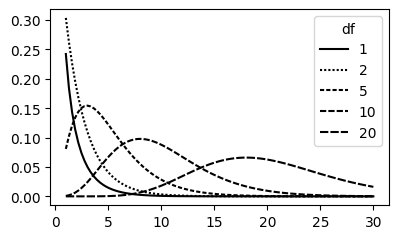

In [27]:
# Gambar 3-?: distribusi chi-square untuk berbagai df
x = [1 + i * (30 - 1) / 99 for i in range(100)]
chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')
plt.tight_layout()
plt.show()

**Interpretasi:** p-value (resampling maupun analitik) sekitar 0,08, yaitu di atas 0,05, sehingga perbedaan klik antar judul **bisa saja kebetulan**.

### 9.3 Fisher's Exact Test
Bila hitungan sel terlalu kecil untuk memenuhi asumsi chi-square, gunakan **Fisher's exact test**, yang menghitung peluang eksak semua tabel yang mungkin dengan total baris/kolom tetap. `scipy.stats.fisher_exact` hanya mendukung tabel 2×2. Untuk tabel lebih besar, perlu pustaka lain (R: `fisher.test`).

### 9.4 Relevansi untuk Data Science
Chi-square dipakai di riset web untuk menilai efek *treatment* pada hitungan (klik, konversi) dan untuk **uji kecocokan** (*goodness of fit*). Contoh klasik: **deteksi kecurangan ilmiah**. Pada kasus Tory Imanishi-Kari, data sel dicurigai karena distribusi digit terakhir terlalu tidak seragam; digit terakhir seharusnya hampir seragam bila data murni.

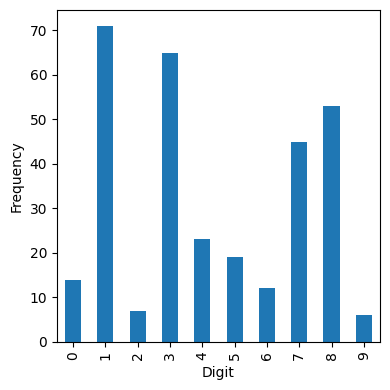

In [28]:
# Distribusi digit terakhir pada data Imanishi-Kari
imanishi = pd.read_csv(IMANISHI_CSV)
imanishi.columns = [c.strip() for c in imanishi.columns]

ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False, figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [29]:
# Tambahan: uji chi-square goodness-of-fit terhadap distribusi seragam
frek = imanishi['Frequency'].values
chisq, p = stats.chisquare(frek)   # H0: seragam
print('Frekuensi digit:', frek)
print(f'chi2 = {chisq:.2f}, p-value = {p:.5f}')

Frekuensi digit: [14 71  7 65 23 19 12 45 53  6]
chi2 = 174.37, p-value = 0.00000


**Interpretasi:** p-value sangat kecil, sehingga distribusi digit **tidak seragam**, indikasi data mungkin telah dimanipulasi atau terpengaruh pola tertentu (pada kasus aslinya ini menjadi salah satu bukti pada investigasi).

### Key Ideas
- Chi-square menguji apakah frekuensi teramati cocok dengan harapan di bawah $H_0$.
- Statistik = jumlah kuadrat residual Pearson; bandingkan dengan distribusi chi-square.
- Gunakan Fisher's exact test bila hitungan sel kecil.

---
## 10. Multi-Arm Bandit Algorithm

**Multi-arm bandit** adalah alternatif A/B test klasik yang **adaptif**: selama eksperimen, lalu lintas dialihkan **bertahap** ke opsi yang tampak lebih baik. Nama berasal dari mesin slot ("one-armed bandit") dengan banyak tuas dengan peluang kemenangan berbeda.

**Istilah kunci**
- **Multi-arm bandit**: mesin slot imajiner dengan banyak tuas; menemukan tuas terbaik sambil memaksimalkan hasil.
- **Arm**: satu perlakuan/opsi dalam eksperimen.
- **Win**: hasil sukses (klik, konversi) pada percobaan.

**Keunggulan:** mengurangi "biaya" mengirim pengunjung ke opsi yang buruk, dan cocok untuk banyak opsi atau eksperimen dengan banyak percobaan (mis. judul berita). **Algoritma sederhana (epsilon-greedy)**: dengan peluang $\epsilon$, pilih opsi acak (eksplorasi); selain itu pilih opsi dengan hasil terbaik sejauh ini (eksploitasi). **Thompson sampling** lebih canggih: tarik sampel dari distribusi Beta tiap opsi, lalu pilih opsi dengan sampel tertinggi. Ini mengalokasikan lebih banyak percobaan ke opsi yang menjanjikan sekaligus tetap menjelajah.

### Key Ideas
- A/B test tradisional menetapkan alokasi tetap; bandit mengadaptasi alokasi secara dinamis.
- Cocok untuk banyak opsi dan keputusan cepat, namun lebih kompleks dianalisis.
- Algoritma populer: epsilon-greedy dan Thompson sampling.

In [30]:
# Tambahan (buku hanya menjelaskan konsep): simulasi epsilon-greedy vs A/B 50/50
rng = np.random.default_rng(3)
p_asli = np.array([0.04, 0.05, 0.07])       # peluang klik sebenarnya tiap opsi (tidak diketahui algoritma)
T, eps = 20_000, 0.1

menang, coba = np.zeros(3), np.zeros(3)
total_bandit = 0
for t in range(T):
    if rng.random() < eps or coba.min() == 0:
        arm = rng.integers(3)                      # eksplorasi
    else:
        arm = np.argmax(menang / coba)             # eksploitasi
    hasil = rng.random() < p_asli[arm]
    menang[arm] += hasil; coba[arm] += 1; total_bandit += hasil

total_ab = (rng.random((T,)) < p_asli[rng.integers(3, size=T)]).sum()   # alokasi seragam
print('Alokasi percobaan bandit :', coba.astype(int))
print('Total klik - bandit      :', int(total_bandit))
print('Total klik - A/B seragam :', int(total_ab))

Alokasi percobaan bandit : [ 1357   874 17769]
Total klik - bandit      : 1362
Total klik - A/B seragam : 1114


---
## 11. Power dan Sample Size

**Power** adalah peluang mendeteksi efek **bila efek itu memang ada**: $\text{power} = 1 - P(\text{Type 2 error})$. Ukuran sampel yang dibutuhkan bergantung pada empat hal yang saling terkait: **effect size**, **ukuran sampel**, **alpha** (tingkat signifikansi), dan **power**. Bila tiga diketahui, yang keempat dapat dihitung.

**Istilah kunci**
- **Effect size**: ukuran minimal efek yang ingin dideteksi (mis. peningkatan konversi 20%).
- **Power**: peluang mendeteksi efek dengan ukuran tertentu.
- **Significance level ($\alpha$)**: tingkat signifikansi yang dipakai pada uji.

**Aturan praktis:** efek yang kecil membutuhkan sampel yang jauh lebih besar. Efek *sangat* kecil mungkin tak layak dideteksi. Sebelum eksperimen, tentukan ukuran sampel agar tidak membuang waktu pada eksperimen yang "tak berdaya" (*underpowered*).

**Contoh buku:** meningkatkan konversi dari 1,1% ke 1,21% (naik 10%) dan dari 1,1% ke 1,65% (naik 50%), dengan $\alpha=0{,}05$ dan power 0,8.

In [31]:
# Ukuran sampel per kelompok: peningkatan konversi 1.1% -> 1.21%
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8,
                              alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116602.391


In [32]:
# Peningkatan konversi 1.1% -> 1.65%
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8,
                              alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5488.408


**Interpretasi:** mendeteksi kenaikan kecil (10%) membutuhkan sampel **puluhan kali lebih besar** (sekitar 116.000 per kelompok) dibanding mendeteksi kenaikan besar (50%, sekitar 5.500 per kelompok). Menentukan *effect size* yang realistis sangat penting sebelum eksperimen.

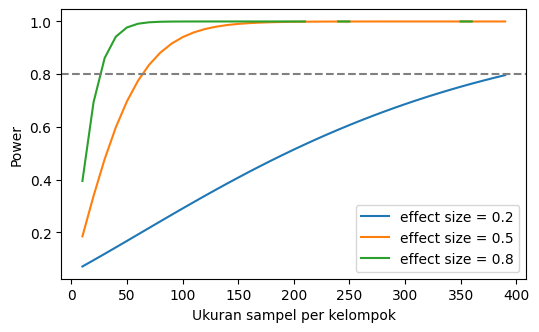

In [33]:
# Tambahan: kurva power vs ukuran sampel untuk beberapa effect size
analysis = sm.stats.TTestIndPower()
ukuran = np.arange(10, 400, 10)
plt.figure(figsize=(6, 3.5))
for es in [0.2, 0.5, 0.8]:
    plt.plot(ukuran, analysis.power(effect_size=es, nobs1=ukuran, alpha=0.05), label=f'effect size = {es}')
plt.axhline(0.8, color='grey', ls='--')
plt.xlabel('Ukuran sampel per kelompok'); plt.ylabel('Power'); plt.legend(); plt.show()

### Key Ideas
- Power = peluang mendeteksi efek yang benar-benar ada.
- Ukuran sampel ditentukan oleh effect size, $\alpha$, dan power.
- Efek kecil butuh sampel besar; hitung sebelum eksperimen.

---
## 12. Ringkasan Bab

Bab 3 membahas cara **merancang eksperimen** dan **menguji apakah hasil nyata atau kebetulan**.

| Konsep | Inti |
|---|---|
| **A/B testing** | Dua kelompok, penugasan acak, satu metrik yang ditentukan di awal |
| **Hypothesis test** | $H_0$ (hanya kebetulan) vs $H_A$; satu arah atau dua arah |
| **Resampling / permutasi** | Acak ulang label kelompok untuk membentuk distribusi referensi tanpa asumsi distribusi |
| **P-value & signifikansi** | Peluang hasil seekstrem itu di bawah $H_0$; bukan peluang $H_0$ benar; waspadai Type 1 dan Type 2 error |
| **t-test** | Uji rata-rata dua kelompok berbasis distribusi t |
| **Multiple testing** | Banyak uji menaikkan false positive; gunakan koreksi/holdout |
| **Degrees of freedom** | Jumlah nilai bebas; penting untuk faktor kategorikal ($P-1$ dummy) |
| **ANOVA** | Uji omnibus >2 kelompok dengan statistik F |
| **Chi-square** | Uji data hitungan; Fisher's exact test untuk sel kecil |
| **Multi-arm bandit** | Eksperimen adaptif yang mengalihkan lalu lintas ke opsi terbaik |
| **Power & sample size** | Hitung ukuran sampel dari effect size, $\alpha$, dan power |

Bab ini melatih intuisi bahwa **kebetulan sering menyerupai pola nyata**. Uji signifikansi adalah alat untuk berhati-hati, bukan jawaban pasti. Konsep *F-statistic*, df, dan t-statistic akan muncul kembali pada **Bab 4 (Regresi)**.